In [1]:
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    VecFrameStack,
    VecEnvWrapper
)
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import json
import time
from collections import defaultdict

gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Inspect the environment 

In [2]:
env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("=== SPACES ===")
print("Obs space: ", env.observation_space)
print("Act space: ", env.action_space)
print("Actions:   ", env.unwrapped.get_action_meanings())

print("\n=== INFO DICT KEYS ===")
print(info)

print("\n=== ALE PROPERTIES ===")
ale = env.unwrapped.ale
print("Lives:          ", ale.lives())
print("Frame number:   ", ale.getFrameNumber())
print("Episode frames: ", ale.getEpisodeFrameNumber())
print("RAM size:       ", len(ale.getRAM()))
print("Legal actions:  ", ale.getLegalActionSet())
print("Min actions:    ", ale.getMinimalActionSet())

env.close()

=== SPACES ===
Obs space:  Box(0, 255, (210, 160, 3), uint8)
Act space:  Discrete(9)
Actions:    ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

=== INFO DICT KEYS ===
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

=== ALE PROPERTIES ===
Lives:           3
Frame number:    0
Episode frames:  0
RAM size:        128
Legal actions:   [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions:     [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


In [3]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.5.1+cu121
True


Reward Shaping Wrapper

In [4]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARD = {200, 400, 800, 1600}
    FRUIT_REWARD = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150

    def __init__(self, env,
                 ghost_chain_bonus=50.0,
                 ghost_hunt_bonus=20.0,
                 missed_ghost_penalty=-15.0,
                 timing_bonus=30.0,
                 pellet_streak_bonus=0.5,
                 fruit_multiplier=2.0, 
                 death_penalty=-25.0,):
        super().__init__(env)
        self.ghost_chain_bonus     = ghost_chain_bonus
        self.ghost_hunt_bonus      = ghost_hunt_bonus
        self.missed_ghost_penalty  = missed_ghost_penalty
        self.timing_bonus    = timing_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty    = death_penalty
       
        # State tracking for reward shaping
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None 
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward 
 
        # Initialise lives tracker 
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power pellet tracking
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                if self.ghosts_eaten == 0:
                    shaped_reward += self.missed_ghost_penalty * 2
                elif self.ghosts_eaten == 1:
                    shaped_reward += self.missed_ghost_penalty
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0

        # Ghost eaten
        elif reward in self.GHOST_REWARD:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
            if self._power_pellet_active:
                    shaped_reward += self.ghost_hunt_bonus

        raw_reward = int(reward)
        # Pellet streak
        if raw_reward == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0

            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
        elif raw_reward == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0

            shaped_reward += self.pellet_streak_bonus * self._pellet_streak

            # Start pellet timer
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
        else:
            self._steps_since_pellet += 1

            # Break if too much without eating a pellet
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0

        # Fruit multiplier
        if raw_reward in self.FRUIT_REWARD:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw_reward

        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
 
        return obs, shaped_reward, terminated, truncated, info

Define the 4 Experimental Conditions

In [5]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "#4C9BE8",
        "description": "Default ALE rewards only"
    },

    "Death Penalty": {
        "wrapper": "simple",
        "survival_bonus": 0.0, 
        "death_penalty": -25.0,
        "power_pellet_bonus": 0.0,
        "color": "#57C97A",
        "description": "-25 on each life lost"
    },

    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 5.0,
        "ghost_hunt_bonus": 2.0,
        "missed_ghost_penalty": -2.0,
        "timing_bonus": 3.0,
        "pellet_streak_bonus": 0.05,
        "fruit_multiplier": 1.1, 
        "death_penalty": -5.0,    
        "color": "#C97AE8",
        "description": "Ghost chain + pellet streak +fruit + death penalty"
    },

    "Expert No Death Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus": 5.0,
        "ghost_hunt_bonus": 2.0,
        "missed_ghost_penalty": -2.0,
        "timing_bonus": 3.0,
        "pellet_streak_bonus": 0.05,
        "fruit_multiplier": 1.1, 
        "death_penalty": 0.0,    
        "color": "#E8C94C",
        "description": "Ghost chain + pellet streak +fruit, no death penalty"
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:20s} — {cfg['description']}")

Conditions defined:
  Baseline             — Default ALE rewards only
  Death Penalty        — -25 on each life lost
  Expert Shaping       — Ghost chain + pellet streak +fruit + death penalty
  Expert No Death Penalty — Ghost chain + pellet streak +fruit, no death penalty


Progress Callback (tracks metrics per episode)

In [6]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose=0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []
        self.episode_lengths = []
        self._current_reward = 0
        self._current_length = 0
 
    def _on_step(self):
        self._current_reward += self.locals["rewards"][0]
        self._current_length += 1
 
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self.episode_lengths.append(self._current_length)
            self._current_reward = 0
            self._current_length = 0
            if len(self.episode_rewards) % 50 == 0:
                recent_r = np.mean(self.episode_rewards[-20:])
                recent_l = np.mean(self.episode_lengths[-20:])
                print(f"  [{self.condition_name}] "
                      f"Ep {len(self.episode_rewards):>4} | "
                      f"Steps {self.num_timesteps:>7,} | "
                      f"Avg reward: {recent_r:>7.1f} | "
                      f"Avg length: {recent_l:>5.0f}")
        return True
 

Training Function

In [7]:
def make_env(condition_name, condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5")
        
        if condition_cfg["wrapper"] == None:
            pass
        elif condition_cfg["wrapper"] == "simple":
            env = RewardShapingWrapper(
                env,
                death_penalty=condition_cfg.get("death_penalty", 0.0),
            )
        elif condition_cfg["wrapper"] == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus=condition_cfg.get("ghost_chain_bonus", 0.0),
                ghost_hunt_bonus=condition_cfg.get("ghost_hunt_bonus", 0.0),
                missed_ghost_penalty=condition_cfg.get("missed_ghost_penalty", 0.0),
                timing_bonus=condition_cfg.get("timing_bonus", 0.0),
                pellet_streak_bonus=condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier=condition_cfg.get("fruit_multiplier", 1.0),
                death_penalty=condition_cfg.get("death_penalty", 0.0),
            )
        
        env = AtariWrapper(env, clip_reward=False)
        return env
    return _init
 
 
def train_condition(condition_name, condition_cfg, total_timesteps=1000000, seed=42):
    print(f"\n{'='*60}")
    print(f"Training: {condition_name}")
    print(f"Config:   {condition_cfg['description']}")

    vec_env = DummyVecEnv([make_env(condition_name, condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)

    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps=128,
        batch_size=256,
        n_epochs=4,
        gamma=0.99,
        learning_rate=2.5e-4,
        clip_range=0.1,
        verbose=0,
        seed=seed,
    )

    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save(f"ppo_pacman_{condition_name.replace(' ', '_').lower()}") 
    
    vec_env.close()
    return model, callback

In [8]:
TOTAL_STEPS = 1_000_000
 
results = {} 
 
for name, cfg in CONDITIONS.items():
    model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS)
    results[name] = {
        "callback": callback,
        "model": model,
        "episode_rewards": callback.episode_rewards,
        "episode_lengths": callback.episode_lengths,
    }
 
print("\nAll conditions trained!")


Training: Baseline
Config:   Default ALE rewards only


c:\Users\artur\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Baseline] Ep   50 | Steps   2,374 | Avg reward:   159.0 | Avg length:    53
  [Baseline] Ep  100 | Steps   4,595 | Avg reward:   112.0 | Avg length:    45
  [Baseline] Ep  150 | Steps   7,065 | Avg reward:   119.5 | Avg length:    46
  [Baseline] Ep  200 | Steps   9,512 | Avg reward:   178.0 | Avg length:    52
  [Baseline] Ep  250 | Steps  12,162 | Avg reward:   150.5 | Avg length:    58
  [Baseline] Ep  300 | Steps  14,727 | Avg reward:   121.5 | Avg length:    47
  [Baseline] Ep  350 | Steps  17,363 | Avg reward:   199.0 | Avg length:    55
  [Baseline] Ep  400 | Steps  19,944 | Avg reward:   181.0 | Avg length:    46
  [Baseline] Ep  450 | Steps  22,367 | Avg reward:   160.5 | Avg length:    48
  [Baseline] Ep  500 | Steps  25,006 | Avg reward:   251.5 | Avg length:    55
  [Baseline] Ep  550 | Steps  27,634 | Avg reward:   269.0 | Avg length:    48
  [Baseline] Ep  600 | Steps  30,197 | Avg reward:   192.0 | Avg length:    48
  [Baseline] Ep  650 | Steps  32,804 | Avg reward:  

c:\Users\artur\AppData\Local\Programs\Python\Python310\lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Death Penalty] Ep   50 | Steps   2,579 | Avg reward:   159.9 | Avg length:    56
  [Death Penalty] Ep  100 | Steps   5,189 | Avg reward:   192.2 | Avg length:    54
  [Death Penalty] Ep  150 | Steps   7,771 | Avg reward:   114.7 | Avg length:    52
  [Death Penalty] Ep  200 | Steps  10,074 | Avg reward:    80.7 | Avg length:    42
  [Death Penalty] Ep  250 | Steps  12,387 | Avg reward:   130.6 | Avg length:    52
  [Death Penalty] Ep  300 | Steps  14,968 | Avg reward:   107.8 | Avg length:    45
  [Death Penalty] Ep  350 | Steps  17,528 | Avg reward:    98.6 | Avg length:    52
  [Death Penalty] Ep  400 | Steps  20,287 | Avg reward:   116.1 | Avg length:    58
  [Death Penalty] Ep  450 | Steps  22,958 | Avg reward:   126.3 | Avg length:    52
  [Death Penalty] Ep  500 | Steps  25,542 | Avg reward:   150.5 | Avg length:    51
  [Death Penalty] Ep  550 | Steps  27,798 | Avg reward:    83.8 | Avg length:    42
  [Death Penalty] Ep  600 | Steps  30,278 | Avg reward:   133.4 | Avg length

Evaluation Function

In [9]:
def evaluate_agent(model, condition_cfg, n_episodes=100, seed=99):
    def make_env_env():
        env = gym.make("ALE/MsPacman-v5")
        env = AtariWrapper(env, clip_reward=False)
        return env
    
    eval_env = DummyVecEnv([make_env_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)

    # Evaluation metrics
    scores = []
    lengths = []
    ghosts_chains = []
    deaths = []
    pellets_eaten = []

    for ep in range(n_episodes):
        obs = eval_env.reset()
        total_score = 0
        length = 0
        done = False
        current_chain = 0
        max_chain = 0
        ep_deaths = 0
        ep_pellets = 0
        prev_lives = 3

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = eval_env.step(action)
            r = reward[0]
            total_score += r
            length += 1

            #Track ghost chaining
            if r in [200, 400, 800, 1600]:
                current_chain += 1
                max_chain = max(max_chain, current_chain)
            elif r == 50:
                current_chain = 0

            # Track deaths
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                ep_deaths += 1
            prev_lives = current_lives

            # Track pellets eaten
            if r == 10:
                ep_pellets += 1

        scores.append(total_score)
        lengths.append(length)
        ghosts_chains.append(max_chain)
        deaths.append(ep_deaths)
        pellets_eaten.append(ep_pellets)

    eval_env.close()
    return {
        "scores": scores,
        "lengths": lengths,
        "ghost_chains": ghosts_chains,
        "deaths": deaths,
        "pellets_eaten": pellets_eaten,
    }

    

Evaluate All Conditions

In [10]:
eval_results = {}
 
for name, data in results.items():
    if data is None:
        print(f"Skipping evaluation for {name} Failed to train")
        continue
    print(f"Evaluating {name}...")
    eval_results[name] = evaluate_agent(data["model"], CONDITIONS[name], n_episodes=100, seed=99)
    score = eval_results[name]["scores"]
    length = eval_results[name]["lengths"]
    ghost_chains = eval_results[name]["ghost_chains"]
    deaths = eval_results[name]["deaths"]
    pellets = eval_results[name]["pellets_eaten"]
    print(f"  Avg score:  {np.mean(score):.1f} ± {np.std(score):.1f}")
    print(f"  Avg length: {np.mean(length):.1f}")
    print(f"  Avg ghost chain: {np.mean(ghost_chains):.2f}")
    print(f"  Avg deaths: {np.mean(deaths):.2f}")
    print(f"  Avg pellets eaten: {np.mean(pellets):.1f}")

Evaluating Baseline...
  Avg score:  144.2 ± 163.0
  Avg length: 39.8
  Avg ghost chain: 0.07
  Avg deaths: 1.66
  Avg pellets eaten: 9.3
Evaluating Death Penalty...
  Avg score:  142.3 ± 147.5
  Avg length: 50.3
  Avg ghost chain: 0.00
  Avg deaths: 1.66
  Avg pellets eaten: 10.2
Evaluating Expert Shaping...
  Avg score:  23.8 ± 33.2
  Avg length: 41.9
  Avg ghost chain: 0.00
  Avg deaths: 1.66
  Avg pellets eaten: 1.7
Evaluating Expert No Death Penalty...
  Avg score:  54.7 ± 55.3
  Avg length: 33.6
  Avg ghost chain: 0.00
  Avg deaths: 1.66
  Avg pellets eaten: 3.8


Learning efficiency analysis 

In [11]:
def smooth(arr, window=50):
    if len(arr) < window:
        return np.array(arr)
    return np.convolve(arr, np.ones(window)/window, mode='valid')
 
def steps_to_threshold(episode_rewards, threshold, window=50):
    smoothed = smooth(episode_rewards, window)
    above = np.where(smoothed >= threshold)[0]
    return int(above[0]) + window if len(above) > 0 else None

# Set threshold as 50% of best mean score across all conditions
best_final = max(
    np.mean(d["episode_rewards"][-100:])
    for d in results.values() if d is not None
)
threshold = best_final * 0.5
 
print(f"Performance threshold (50% of best): {threshold:.1f}\n")
print(f"{'Condition':<22} {'Episodes to threshold':>22} {'Final avg (last 100ep)':>23}")
print("-" * 70)
 
efficiency = {}
for name, data in results.items():
    if data is None:
        continue
    ep = steps_to_threshold(data["episode_rewards"], threshold)
    final_avg = np.mean(data["episode_rewards"][-100:])
    efficiency[name] = {"episodes_to_threshold": ep, "final_avg": final_avg}
    ep_str = f"{ep}" if ep is not None else "Never reached"
    print(f"{name:<22} {ep_str:>22} {final_avg:>23.1f}")
    

Performance threshold (50% of best): 191.9

Condition               Episodes to threshold  Final avg (last 100ep)
----------------------------------------------------------------------
Baseline                                  355                   254.3
Death Penalty                              50                   383.7
Expert Shaping                            526                   209.8
Expert No Death Penalty                     52                   310.9


Reward Hacking Detection 

In [12]:
print("REWARD HACKING ANALYSIS")
print("="*60)
print(f"{'Condition':<22} {'Train reward':>14} {'Eval score':>12} {'Hacking?':>10}")
print("-"*60)
 
for name, data in results.items():
    if data is None or name not in eval_results:
        continue
    train_reward = np.mean(data["episode_rewards"][-100:])
    eval_score   = np.mean(eval_results[name]["scores"])
    baseline_eval = eval_results.get("Baseline", {}).get("scores", np.array([0]))
    
    # Hacking signal: shaped reward is high but eval score
    # is LOWER than baseline
    is_hacking = (
        train_reward > np.mean(results["Baseline"]["episode_rewards"][-100:])
        and eval_score < np.mean(baseline_eval)
    )
    hacking_str = "POSSIBLE" if is_hacking else "No"
    print(f"{name:<22} {train_reward:>14.1f} {eval_score:>12.1f} {hacking_str:>10}")
 
print()
print("Reward hacking = shaped reward rises but true game score falls")
print("This would mean agent optimised the wrapper, not the real game")

REWARD HACKING ANALYSIS
Condition                Train reward   Eval score   Hacking?
------------------------------------------------------------
Baseline                        254.3        144.2         No
Death Penalty                   383.7        142.3   POSSIBLE
Expert Shaping                  209.8         23.8         No
Expert No Death Penalty          310.9         54.7   POSSIBLE

Reward hacking = shaped reward rises but true game score falls
This would mean agent optimised the wrapper, not the real game


Statistical Summary Table

In [13]:
print("FULL STATISTICAL SUMMARY")
print("="*85)
print(f"{'Condition':<22} {'Mean±Std Score':>18} {'Max':>6} "
      f"{'Survival':>10} {'Chain':>7} {'Deaths':>8}")
print("-"*85)
 
for name, er in eval_results.items():
    s  = er["scores"]
    l  = er["lengths"]
    g  = er["ghost_chains"]
    d  = er["deaths"]
    print(f"{name:<22} "
          f"{np.mean(s):>8.1f}±{np.std(s):<8.1f} "
          f"{np.max(s):>6.0f} "
          f"{np.mean(l):>10.1f} "
          f"{np.mean(g):>7.2f} "
          f"{np.mean(d):>8.2f}")
 
print("="*85)
print("n=100 evaluation episodes per condition, seed=99, epsilon=0")

FULL STATISTICAL SUMMARY
Condition                  Mean±Std Score    Max   Survival   Chain   Deaths
-------------------------------------------------------------------------------------
Baseline                  144.2±163.0       410       39.8    0.07     1.66
Death Penalty             142.3±147.5       370       50.3    0.00     1.66
Expert Shaping             23.8±33.2         70       41.9    0.00     1.66
Expert No Death Penalty     54.7±55.3        220       33.6    0.00     1.66
n=100 evaluation episodes per condition, seed=99, epsilon=0


Plot 1: Learning Curve

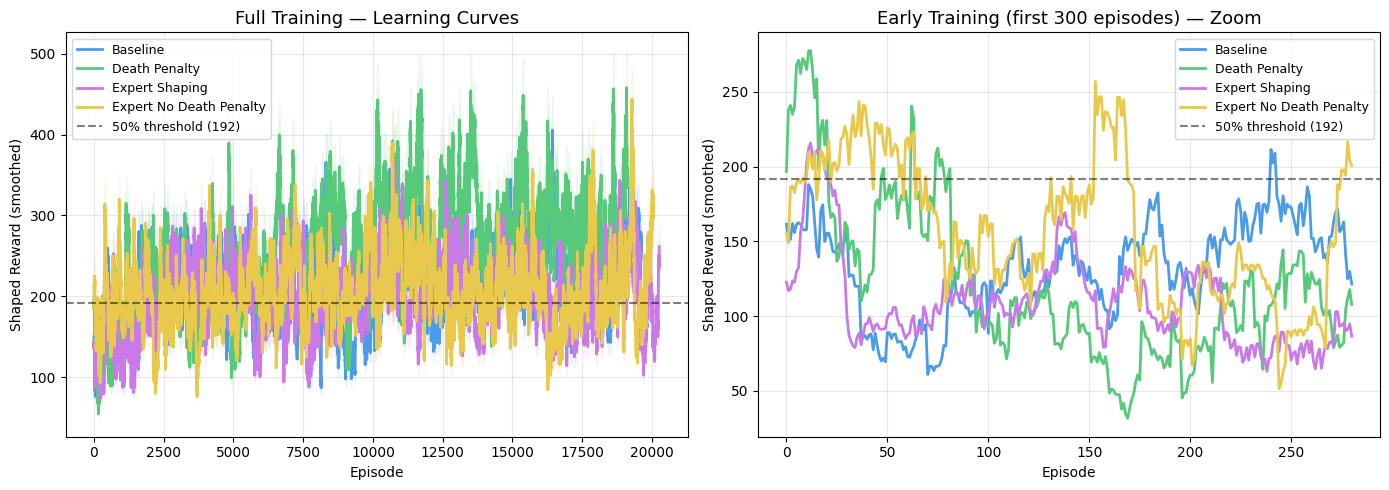

Saved plot_learning_curves.png
USE IN: Analysis section — learning efficiency comparison


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for name, data in results.items():
    if data is None:
        continue
    cfg      = CONDITIONS[name]
    rewards  = data["episode_rewards"]
    smoothed = smooth(rewards, window=50)
    episodes = np.arange(len(smoothed))
 
    # Left plot — smoothed learning curve
    axes[0].plot(episodes, smoothed,
                 color=cfg["color"], linewidth=2, label=name)
    axes[0].fill_between(episodes, smoothed * 0.9, smoothed * 1.1,
                          color=cfg["color"], alpha=0.1)
 
    # Right plot — first 200 episodes zoomed in (early learning)
    early_smoothed = smooth(rewards[:300], window=20)
    axes[1].plot(np.arange(len(early_smoothed)), early_smoothed,
                 color=cfg["color"], linewidth=2, label=name)
 
# Threshold line
for ax in axes:
    ax.axhline(y=threshold, color="black", linestyle="--",
               alpha=0.5, label=f"50% threshold ({threshold:.0f})")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Shaped Reward (smoothed)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
 
axes[0].set_title("Full Training — Learning Curves", fontsize=13)
axes[1].set_title("Early Training (first 300 episodes) — Zoom", fontsize=13)
 
plt.tight_layout()
plt.savefig("plot_learning_curves.png", dpi=130)
plt.show()
print("Saved plot_learning_curves.png")
print("USE IN: Analysis section — learning efficiency comparison")

Plot 2: Final Performance Bar Charts

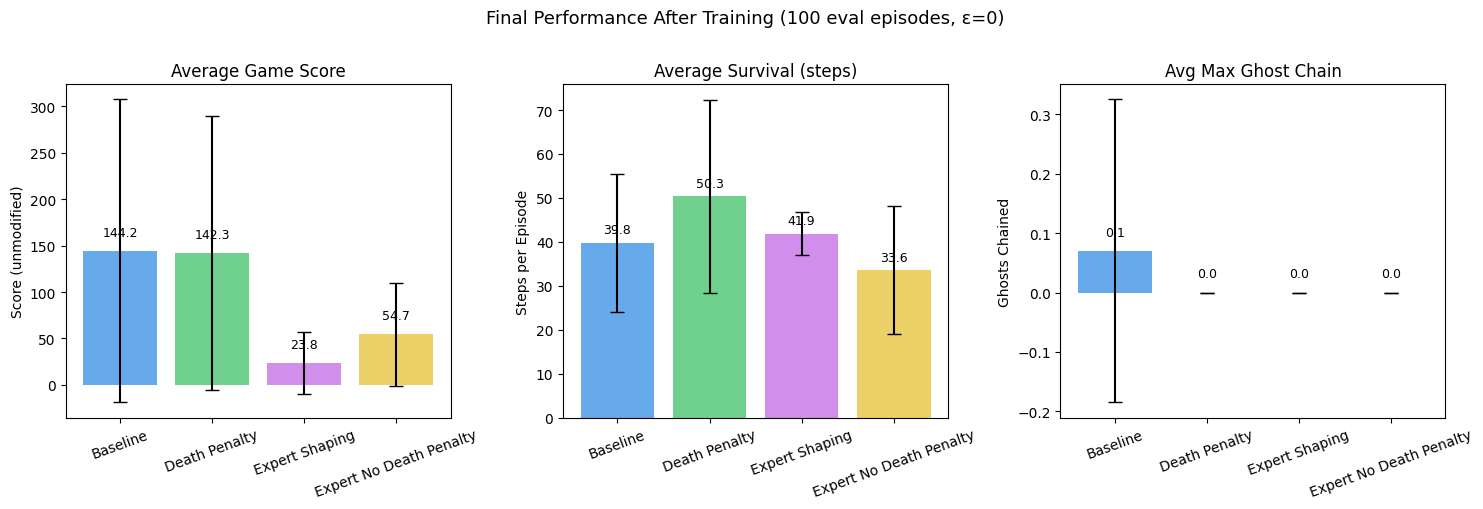

Saved plot_final_performance.png
USE IN: Analysis section — final performance comparison


In [15]:
names  = list(eval_results.keys())
colors = [CONDITIONS[n]["color"] for n in names]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
metrics = [
    ("scores",       "Average Game Score",        "Score (unmodified)"),
    ("lengths",      "Average Survival (steps)",  "Steps per Episode"),
    ("ghost_chains", "Avg Max Ghost Chain",        "Ghosts Chained"),
]
 
for ax, (metric, title, ylabel) in zip(axes, metrics):
    vals = [np.mean(eval_results[n][metric]) for n in names]
    stds = [np.std(eval_results[n][metric])  for n in names]
    bars = ax.bar(names, vals, color=colors, alpha=0.85,
                  yerr=stds, capsize=5)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) * 0.1,
                f"{val:.1f}", ha="center", fontsize=9)
 
plt.suptitle("Final Performance After Training (100 eval episodes, ε=0)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plot_final_performance.png", dpi=130)
plt.show()
print("Saved plot_final_performance.png")
print("USE IN: Analysis section — final performance comparison")

Plot 3: Scpre Distribution Box Plot 

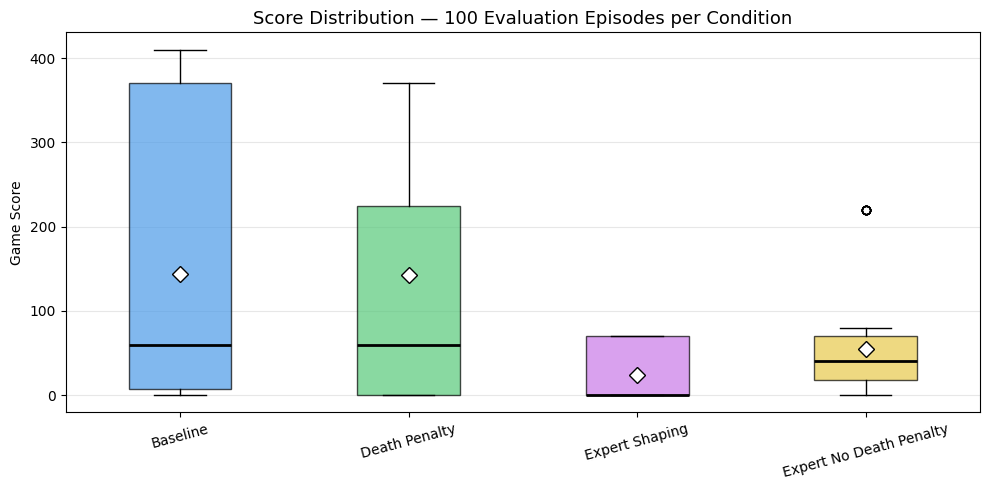

Saved: plot_score_distribution.png
Diamond = mean, line = median
USE IN: Analysis section — consistency and variance comparison


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
data_to_plot = [eval_results[n]["scores"] for n in names]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2))
 
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
 
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("Game Score")
ax.set_title("Score Distribution — 100 Evaluation Episodes per Condition",
             fontsize=13)
ax.grid(axis="y", alpha=0.3)
 
# Add mean markers
for i, n in enumerate(names):
    mean_val = np.mean(eval_results[n]["scores"])
    ax.plot(i + 1, mean_val, "D", color="white",
            markeredgecolor="black", markersize=8, zorder=5)
 
plt.tight_layout()
plt.savefig("plot_score_distribution.png", dpi=130)
plt.show()
print("Saved: plot_score_distribution.png")
print("Diamond = mean, line = median")
print("USE IN: Analysis section — consistency and variance comparison")

Plot 4: Behavioural Radar Chart 

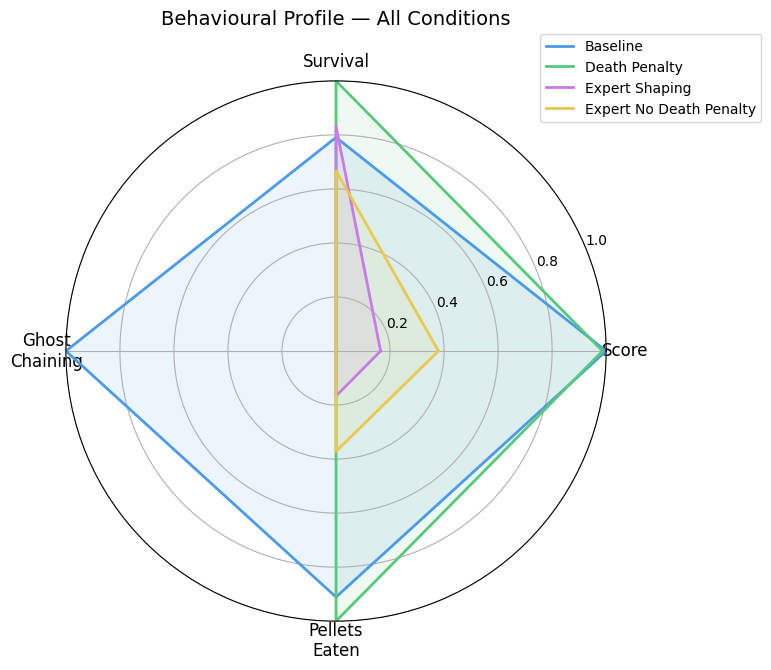

Saved plot_radar.png
USE IN: Analysis section — behavioural profile comparison


In [17]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
 
# Normalise all metrics to 0-1 for radar
metric_keys   = ["scores", "lengths", "ghost_chains", "pellets_eaten"]
metric_labels = ["Score", "Survival", "Ghost\nChaining", "Pellets\nEaten"]
n_metrics     = len(metric_keys)
 
# Compute max for normalisation
maxes = {k: max(np.mean(eval_results[n][k]) for n in names) + 1e-9
         for k in metric_keys}
 
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # close the polygon
 
fig, ax = plt.subplots(figsize=(8, 8),
                        subplot_kw=dict(polar=True))
 
for name in names:
    cfg    = CONDITIONS[name]
    values = [np.mean(eval_results[name][k]) / maxes[k] for k in metric_keys]
    values += values[:1]
    ax.plot(angles, values, color=cfg["color"], linewidth=2, label=name)
    ax.fill(angles, values, color=cfg["color"], alpha=0.1)
 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Behavioural Profile — All Conditions", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
ax.grid(True)
 
plt.tight_layout()
plt.savefig("plot_radar.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved plot_radar.png")
print("USE IN: Analysis section — behavioural profile comparison")

Research Question Answer Matrix

In [18]:
print("RESEARCH QUESTION ANSWER MATRIX")
print("="*75)
print()
print("RQ1: Does strategy-informed shaping outperform naive shaping?")
print("-"*75)
baseline_score = np.mean(eval_results.get("Baseline", {}).get("scores", np.array([0])))
for name, er in eval_results.items():
    diff = np.mean(er["scores"]) - baseline_score
    better = "✓ BEATS baseline" if diff > 0 else "✗ BELOW baseline"
    print(f"  {name:<25} score diff vs baseline: {diff:>+7.1f}  {better}")
 
print()
print("RQ2: Did shaping alter behaviour beyond score?")
print("-"*75)
baseline_length = np.mean(eval_results.get("Baseline", {}).get("lengths", np.array([0])))
baseline_chain  = np.mean(eval_results.get("Baseline", {}).get("ghost_chains", np.array([0])))
for name, er in eval_results.items():
    length_diff = np.mean(er["lengths"]) - baseline_length
    chain_diff  = np.mean(er["ghost_chains"]) - baseline_chain
    print(f"  {name:<25} survival: {length_diff:>+6.1f} steps  |  "
          f"ghost chain: {chain_diff:>+5.2f}")
 
print()
print("RQ3: Is there evidence of reward hacking?")
print("-"*75)
for name, data in results.items():
    if data is None or name not in eval_results:
        continue
    train_r = np.mean(data["episode_rewards"][-100:])
    eval_s  = np.mean(eval_results[name]["scores"])
    baseline_train = np.mean(results["Baseline"]["episode_rewards"][-100:])
    hacking = train_r > baseline_train and eval_s < baseline_score
    print(f"  {name:<25} train_reward={train_r:>7.1f}  "
          f"eval_score={eval_s:>7.1f}  hacking={'YES ⚠' if hacking else 'no'}")
 
print()
print("="*75)
print("This matrix is your evidence that you answered all 3 research questions.")

RESEARCH QUESTION ANSWER MATRIX

RQ1: Does strategy-informed shaping outperform naive shaping?
---------------------------------------------------------------------------
  Baseline                  score diff vs baseline:    +0.0  ✗ BELOW baseline
  Death Penalty             score diff vs baseline:    -1.9  ✗ BELOW baseline
  Expert Shaping            score diff vs baseline:  -120.4  ✗ BELOW baseline
  Expert No Death Penalty   score diff vs baseline:   -89.5  ✗ BELOW baseline

RQ2: Did shaping alter behaviour beyond score?
---------------------------------------------------------------------------
  Baseline                  survival:   +0.0 steps  |  ghost chain: +0.00
  Death Penalty             survival:  +10.5 steps  |  ghost chain: -0.07
  Expert Shaping            survival:   +2.1 steps  |  ghost chain: -0.07
  Expert No Death Penalty   survival:   -6.2 steps  |  ghost chain: -0.07

RQ3: Is there evidence of reward hacking?
------------------------------------------------------